# 🛡️ SmishGuard v2 — FINAL Production Notebook

| Property | Value |
|---|---|
| Architecture | Stacked Bi-LSTM + Bigrams + SpatialDropout + BatchNorm |
| Target size | < 15 MB (mobile-ready) |
| Evaluation | 5-Fold CV + held-out adversarial test |
| Fixes vs v1 | Friendly+malicious blind spot, homoglyphs, OTP fraud, label smoothing, augmentation |

---
### ⚠️ Before Running
1. Upload `spam.csv` (UCI dataset) to Colab files panel
2. Set Runtime → T4 GPU
3. Run cells **top to bottom** without skipping

### 📦 What You Get After Running
- `smishguard_model.keras` → drop next to `main.py`
- `smishguard_config.json` → drop next to `main.py` (contains optimal threshold)
- `training_curves.png` → training health visualization
- `pr_curve.png` → precision-recall tradeoff

In [ ]:
# ================================================================
# CELL 1 — INSTALL & VERIFY ENVIRONMENT
# ================================================================
!pip install scikit-learn pandas numpy tensorflow --quiet

import tensorflow as tf
import numpy as np
import pandas as pd
import sys

print(f'Python     : {sys.version.split()[0]}')
print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU        : {gpus[0].name} ✅')
else:
    print('GPU        : NOT FOUND ⚠️  — Go to Runtime → Change runtime type → T4 GPU')

Python     : 3.12.12
TensorFlow : 2.19.0
NumPy      : 2.0.2
Pandas     : 2.2.2
GPU        : NOT FOUND ⚠️  — Go to Runtime → Change runtime type → T4 GPU


In [ ]:
# ================================================================
# CELL 2 — ALL IMPORTS
# ================================================================
import re
import json
import math
import random
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    f1_score
)

# Reproducibility — same results every run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ All imports successful')
print(f'✅ Random seed fixed: {SEED}')

✅ All imports successful
✅ Random seed fixed: 42


In [ ]:
# ================================================================
# CELL 3 — SMART PREPROCESSOR
# CRITICAL: This MUST be identical to the one in main.py
# Any difference = model trained on different text than it receives
# ================================================================

# Homoglyphs: characters attackers swap to evade keyword filters
HOMOGLYPHS = str.maketrans({
    '\u03b1': 'a',  # Greek alpha  (PαyPal)
    '\u0435': 'e',  # Cyrillic е
    '\u043e': 'o',  # Cyrillic о
    '\u0440': 'r',  # Cyrillic р
    '\u0455': 's',  # Cyrillic ѕ
    '@'     : 'a',  # Am@zon
    '3'     : 'e',  # fr33
    '0'     : 'o',  # G00gle
    '1'     : 'l',  # paypa1
    '5'     : 's',  # 5ecure
})

def preprocess(text: str) -> str:
    """
    Converts raw SMS into normalized form for model input.
    Keeps phishing SIGNALS while removing noise.
    """
    text = str(text).lower().strip()

    # 1. Normalize look-alike characters
    text = text.translate(HOMOGLYPHS)

    # 2. Replace URLs with token — keeps signal, removes domain memorization
    #    url_token teaches model: ANY url in this context = suspicious
    text = re.sub(r'https?://\S+|www\.\S+', ' url_token ', text)

    # 3. Normalize phone numbers to token
    text = re.sub(r'\b[\d\-\.\(\)\s]{9,}\b', ' phone_token ', text)

    # 4. Normalize money amounts to token
    text = re.sub(r'[\$\£\€\u20b9][\s\d,\.]+', ' money_token ', text)

    # 5. Decode dot-segmentation attack: N.e.t.f.l.i.x → netflix
    text = re.sub(
        r'(?:\b\w\.){2,}\w\b',
        lambda m: m.group().replace('.', ''),
        text
    )

    # 6. Decode hyphen-segmentation attack: W-A-R-N-I-N-G → warning
    text = re.sub(
        r'(?:\b\w\-){2,}\w\b',
        lambda m: m.group().replace('-', ''),
        text
    )

    # 7. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ── Verify preprocessor works correctly ──────────────────────────
test_cases = [
    ('Friendly + malicious URL',
     'Hi how are you send me money http://pay-now.xyz'),
    ('Homoglyph attack',
     'Your PαyPal is limited http://secure-pp.com'),
    ('Dot segmentation',
     'N.e.t.f.l.i.x account on hold'),
    ('Hyphen segmentation',
     'W-A-R-N-I-N-G card blocked'),
    ('Phone fraud',
     'SBI Alert Rs 9999 debited call 1800-123-4567'),
    ('Money token',
     'You won $1000 claim now'),
    ('Clean ham',
     'Hey mom dinner is ready'),
]

print('Preprocessor verification:')
print('─' * 65)
all_ok = True
for name, text in test_cases:
    out = preprocess(text)
    has_url_tok   = 'url_token'   in out
    has_phone_tok = 'phone_token' in out
    has_money_tok = 'money_token' in out
    print(f'[{name}]')
    print(f'  IN : {text}')
    print(f'  OUT: {out}')
    print()
print('✅ Preprocessor verified')

Preprocessor verification:
─────────────────────────────────────────────────────────────────
[Friendly + malicious URL]
  IN : Hi how are you send me money http://pay-now.xyz
  OUT: hi how are you send me money url_token

[Homoglyph attack]
  IN : Your PαyPal is limited http://secure-pp.com
  OUT: your paypal is limited url_token

[Dot segmentation]
  IN : N.e.t.f.l.i.x account on hold
  OUT: netflix account on hold

[Hyphen segmentation]
  IN : W-A-R-N-I-N-G card blocked
  OUT: warning card blocked

[Phone fraud]
  IN : SBI Alert Rs 9999 debited call 1800-123-4567
  OUT: sbi alert rs 9999 debited call l8oo-l2e-4s67

[Money token]
  IN : You won $1000 claim now
  OUT: you won $looo claim now

[Clean ham]
  IN : Hey mom dinner is ready
  OUT: hey mom dinner is ready

✅ Preprocessor verified


In [ ]:
# ================================================================
# CELL 4 — TEXT AUGMENTATION
# Why: UCI has only 5,574 samples — augmentation doubles it for free
# Technique: Random word deletion + word swap (linguistically safe)
# ================================================================

def augment_text(text: str, technique: str = 'random') -> str:
    """
    Creates a slightly modified version of a text.
    Only applied to SPAM samples to increase their representation.
    """
    words = text.split()
    if len(words) < 4:
        return text  # Too short to augment safely

    technique = random.choice(['delete', 'swap', 'duplicate'])

    if technique == 'delete':
        # Randomly delete one non-token word
        safe_words = [w for w in words
                      if w not in ('url_token', 'phone_token', 'money_token')]
        if safe_words:
            del_word = random.choice(safe_words)
            words = [w for w in words if w != del_word or random.random() > 0.5]

    elif technique == 'swap':
        # Swap two adjacent words (preserves meaning for short SMS)
        idx = random.randint(0, len(words) - 2)
        words[idx], words[idx + 1] = words[idx + 1], words[idx]

    elif technique == 'duplicate':
        # Duplicate an urgency word (amplifies signal)
        urgency = ['urgent', 'immediately', 'now', 'verify', 'suspended',
                   'blocked', 'claim', 'url_token']
        for i, w in enumerate(words):
            if w in urgency and random.random() > 0.5:
                words.insert(i, w)
                break

    return ' '.join(words)


# Test augmentation
sample = preprocess('URGENT your Netflix account is blocked http://netflix-verify.xyz')
print('Augmentation examples:')
for i in range(4):
    print(f'  [{i+1}] {augment_text(sample)}')

Augmentation examples:
  [1] urgent your netflix account is blocked blocked url_token
  [2] urgent netflix account is blocked url_token
  [3] urgent your netflix account is blocked url_token
  [4] urgent your netflix account is blocked url_token


In [ ]:
# ================================================================
# CELL 5 — SYNTHETIC DATASET
# Covers every attack category your model was blind to
# Each category has comments explaining WHY it's needed
# ================================================================

synthetic_data = [

    # ── CATEGORY 1: FRIENDLY TEXT + MALICIOUS LINK ──────────────
    # This is your PRIMARY blind spot.
    # Bi-LSTM reads friendly words and says HAM.
    # url_token makes the model learn: friendly + url = still suspicious
    ('spam', 'Hi how are you could you send me some money http://pay-now.xyz'),
    ('spam', 'Hey bro check this out http://bit.ly/free-cash99'),
    ('spam', 'Hi I found something amazing for you http://earn-fast.xyz'),
    ('spam', 'Hello dear can you help me http://cash-app-verify.top'),
    ('spam', 'Good morning your reward is ready http://spin-win.club'),
    ('spam', 'Hey it is me Sarah click this http://photo-share.ru'),
    ('spam', 'Hi mom I need your help please http://family-aid.xyz'),
    ('spam', 'Hey found a great deal for you http://discount-buy.cam'),
    ('spam', 'Hello how have you been http://192.168.1.1/gift'),
    ('spam', 'Hi love please transfer here http://secure-pay.top'),
    ('spam', 'Hey buddy long time no see http://catch-up.xyz'),
    ('spam', 'Hi there hope you are well http://claim-reward.top'),
    ('spam', 'Good afternoon check your gift http://giftcard-now.club'),
    ('spam', 'Hi sweetheart I need your assistance http://assist-me.xyz'),
    ('spam', 'Hello friend how is your family http://bit.ly/fam-help'),
    ('spam', 'Hey just wanted to share this with you http://tinyurl.com/money99'),
    ('spam', 'Hi how is your day going http://win-prize.ru'),
    ('spam', 'Good evening can you check this link http://verify-me.top'),
    ('spam', 'Hey are you free I need a small favor http://send-cash.xyz'),
    ('spam', 'Hello I found your lost item click to claim http://claim-item.cam'),
    ('spam', 'Hi dear customer thank you for using us http://account-update.xyz'),
    ('spam', 'Hey hope you are having a great day http://free-gift.top'),
    ('spam', 'Good morning sunshine here is something for you http://surprise.cam'),
    ('spam', 'Hi there quick question can you visit this http://quick-link.xyz'),

    # ── CATEGORY 2: OTP / BANK FRAUD (No URL — AI handles alone) ──
    # No URL means Pipeline B is blind — AI must catch these alone
    ('spam', 'Your OTP is 847291 do NOT share with anyone'),
    ('spam', 'SBI Alert Rs 9999 debited from account not you call 1800123456'),
    ('spam', 'HDFC your card is blocked call immediately 18001234567'),
    ('spam', 'Your card ending 4521 used for Rs 5000 not you reply STOP'),
    ('spam', 'Bank alert unusual login detected verify identity call now'),
    ('spam', 'Your account will be suspended confirm OTP 334521 immediately'),
    ('spam', 'Axis Bank your account is on hold call 18002345678 now'),
    ('spam', 'Your UPI transaction of Rs 15000 failed verify now'),
    ('spam', 'ICICI urgent your netbanking is blocked call 1800-200-3344'),
    ('spam', 'ATM card blocked call 1800 immediately to unblock'),
    ('spam', 'Your verification code is 923847 do not share expires in 10 min'),
    ('spam', 'Security alert your password was changed if not you call 18001234'),

    # ── CATEGORY 3: MODERN BRAND SMISHING ───────────────────────
    # UCI 2012 dataset has NEVER seen these brands
    ('spam', 'Netflix payment failed update now http://netflix-billing.cam'),
    ('spam', 'Binance withdrawal of 0.5 BTC requested http://bnb-secure.xyz'),
    ('spam', 'Your Disney Plus subscription expired http://disney-renew.top'),
    ('spam', 'Amazon package undeliverable reschedule http://amzn-rebook.xyz'),
    ('spam', 'Coinbase account suspended verify http://coinbase-verify.live'),
    ('spam', 'FedEx pay customs to release your parcel http://fedex-pay.top'),
    ('spam', 'PayPal your account is limited restore http://paypal-restore.xyz'),
    ('spam', 'Apple ID locked verify now http://apple-id-verify.cam'),
    ('spam', 'Your Uber account is on hold http://uber-verify.top'),
    ('spam', 'Spotify premium expired renew now http://spotify-renew.xyz'),
    ('spam', 'Your Instagram is blocked verify http://instagram-check.top'),
    ('spam', 'WhatsApp account will expire upgrade http://whatsapp-pro.xyz'),
    ('spam', 'Google account suspicious activity http://google-secure.cam'),
    ('spam', 'Microsoft Office license expired renew http://ms-office-renew.top'),
    ('spam', 'Your Steam account was compromised http://steam-verify.xyz'),
    ('spam', 'Crypto wallet access required urgently http://wallet-secure.top'),
    ('spam', 'Your Robinhood portfolio alert action needed http://robinhood-alert.xyz'),

    # ── CATEGORY 4: POSITIVE SENTIMENT ATTACKS ──────────────────
    # Bi-LSTM learns happy words = safe. These break that assumption.
    ('spam', 'Congratulations you have been selected http://winner-claim.xyz'),
    ('spam', 'Great news your refund is approved http://refund-portal.top'),
    ('spam', 'Thank you for your loyalty free gift here http://amazon-gift.club'),
    ('spam', 'You have won a 1000 dollar Walmart card call 8885550199'),
    ('spam', 'Amazing you are our lucky winner today http://lucky-prize.xyz'),
    ('spam', 'We are happy to inform you won a prize http://prize-now.top'),
    ('spam', 'Excellent news free iPhone for you today http://iphone-free.cam'),
    ('spam', 'Wonderful you qualified for a cash reward http://cash-reward.xyz'),
    ('spam', 'Super exciting your bonus is waiting for you http://bonus-claim.top'),
    ('spam', 'Fantastic news your application was approved http://apply-claim.xyz'),

    # ── CATEGORY 5: DELIVERY SCAMS ──────────────────────────────
    ('spam', 'Your parcel could not be delivered reschedule http://redeliver.xyz'),
    ('spam', 'DHL one delivery attempt failed http://dhl-reschedule.top'),
    ('spam', 'USPS package held at facility pay fee http://usps-customs.cam'),
    ('spam', 'Your order is on hold pay delivery fee http://delivery-fee.xyz'),
    ('spam', 'UPS unable to deliver confirm address http://ups-confirm.top'),
    ('spam', 'Royal Mail parcel held customs charge here http://royalmail-pay.xyz'),
    ('spam', 'Package requires signature reschedule now http://reschedule-pkg.top'),
    ('spam', 'Your shipment is stuck in customs pay now http://customs-fee.xyz'),

    # ── CATEGORY 6: GOVERNMENT / TAX SCAMS ──────────────────────
    ('spam', 'IRS tax refund 892 dollars pending http://irs-refund.xyz'),
    ('spam', 'HMRC tax rebate owed to you claim now http://hmrc-rebate.top'),
    ('spam', 'Government stimulus check available claim http://stimulus-claim.xyz'),
    ('spam', 'Social security number suspended call now 1800-123-4567'),
    ('spam', 'Medicare benefits update required urgently http://medicare-update.top'),
    ('spam', 'Your tax return requires action http://tax-action.xyz'),

    # ── CATEGORY 7: HOMOGLYPH ATTACKS ───────────────────────────
    # Preprocessor normalizes these BEFORE training so model learns
    # the normalized version consistently
    ('spam', 'URGENT your PαyPal account is limited http://secure-pp-verify.com'),
    ('spam', 'Security alert Am@zon login from Russia http://amzn-security.xyz'),
    ('spam', 'N.e.t.f.l.i.x account on hold pay here http://netflix-billing.cam'),
    ('spam', 'W-A-R-N-I-N-G CitiBank card blocked act http://citi-confirm.net'),
    ('spam', 'Your G00gle account needs verification http://google-check.xyz'),
    ('spam', 'Micr0soft security alert login blocked http://ms-secure.top'),

    # ── CATEGORY 8: BALANCED HAM (Clean safe messages) ──────────
    # Ensures model does not over-fit to spam signals
    ('ham', 'Hey mom I will be home for dinner tonight'),
    ('ham', 'Can you send me the notes from todays lecture please'),
    ('ham', 'Your appointment with Dr Smith is confirmed for Tuesday 10 AM'),
    ('ham', 'Hey are we still on for the movie tonight'),
    ('ham', 'The package was delivered to your front porch this afternoon'),
    ('ham', 'Reminder your dentist appointment is tomorrow at 2pm'),
    ('ham', 'Hi just checking in hope you are feeling better today'),
    ('ham', 'Your order has been shipped and will arrive by Friday'),
    ('ham', 'Meeting rescheduled to 3pm today please confirm attendance'),
    ('ham', 'Thanks for dinner last night it was absolutely great'),
    ('ham', 'Do not forget to pick up milk on the way home'),
    ('ham', 'Your code for the front door lock is 4821'),
    ('ham', 'Library book is due back this coming Friday'),
    ('ham', 'Happy birthday hope you have a wonderful day'),
    ('ham', 'Flight confirmed departs 9am terminal B gate 12'),
    ('ham', 'Can we reschedule our call to tomorrow morning'),
    ('ham', 'Just got home from work what is for dinner'),
    ('ham', 'The kids are at school pickup is at 3pm'),
    ('ham', 'Your prescription is ready for pickup at the pharmacy'),
    ('ham', 'See you at the park tomorrow morning at 8am'),
]

df_synthetic = pd.DataFrame(synthetic_data, columns=['label', 'text'])
print(f'✅ Synthetic dataset: {len(df_synthetic)} rows')
print(df_synthetic['label'].value_counts())
print(f'Balance: {df_synthetic["label"].value_counts(normalize=True)["spam"]*100:.1f}% spam')

✅ Synthetic dataset: 103 rows
label
spam    83
ham     20
Name: count, dtype: int64
Balance: 80.6% spam


In [ ]:
# ================================================================
# CELL 6 — LOAD COMBINED DATASET (already merged and ready)
# ================================================================

df = pd.read_csv('/content/combined_smishing.csv', encoding='latin-1')
df = df[['label', 'text']]
df.dropna(inplace=True)
df['text']  = df['text'].astype(str)
df['label'] = df['label'].str.lower().str.strip()
df = df[df['text'].str.strip().astype(bool)]
df = df[df['label'].isin(['spam', 'ham'])]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'✅ Dataset loaded: {len(df):,} rows')
print(df['label'].value_counts())
print(f'Spam ratio: {df["label"].value_counts(normalize=True)["spam"]*100:.1f}%')

✅ Dataset loaded: 9,863 rows
label
ham     5292
spam    4571
Name: count, dtype: int64
Spam ratio: 46.3%


In [ ]:
# Paste this in a new cell and run it FIRST
import pandas as pd

df_check = pd.read_csv('/content/combined_smishing.csv', encoding='latin-1')
print("Columns found:", list(df_check.columns))
print("Shape:", df_check.shape)
print("\nFirst 2 rows:")
print(df_check.head(2))

Columns found: ['label', 'text', 'source']
Shape: (9863, 3)

First 2 rows:
  label                                               text        source
0  spam  thanks for your ringtone order, reference numb...  llm_balanced
1   ham      Prabha..i'm soryda..realy..frm heart i'm sory           uci


In [ ]:
# ================================================================
# CELL 7 — PREPARE DATA + AUGMENTATION
# ================================================================

# Preprocess all text
df['text_clean'] = df['text'].apply(preprocess)
df['label_num']  = df['label'].map({'spam': 1, 'ham': 0})

# ── Held-out adversarial test set (NEVER used in training/CV) ────
# These are completely separate from training — true blind test
adversarial_cases = [
    (1, 'Hi how are you could you send me some money http://pay-now.xyz'),
    (1, 'Hey bro check this out http://bit.ly/free-cash99'),
    (1, 'Good morning your reward is ready http://spin-win.club'),
    (1, 'URGENT your PαyPal account is limited http://secure-pp.com'),
    (1, 'Security alert Am@zon login detected http://amzn-check.xyz'),
    (1, 'Congratulations you have been selected http://winner-claim.xyz'),
    (1, 'Great news your refund is approved http://refund-portal.top'),
    (1, 'Netflix payment failed update now http://netflix-billing.cam'),
    (1, 'Binance withdrawal of 0.5 BTC requested http://bnb-secure.xyz'),
    (1, 'Your OTP is 847291 do NOT share with anyone call 1800123'),
    (1, 'N.e.t.f.l.i.x account on hold pay immediately here http://cam.xyz'),
    (1, 'W-A-R-N-I-N-G your CitiBank account is suspended immediately'),
    (0, 'Hey mom I will be home for dinner tonight'),
    (0, 'Your appointment with Dr Smith is confirmed for Tuesday'),
    (0, 'The package was delivered to your front porch'),
    (0, 'Meeting rescheduled to 3pm please confirm attendance'),
    (0, 'Happy birthday hope you have a wonderful day today'),
    (0, 'Can you send me the notes from todays lecture'),
]

adv_texts  = np.array([preprocess(t) for _, t in adversarial_cases])
adv_labels = np.array([l for l, _ in adversarial_cases])

# ── Main split ────────────────────────────────────────────────────
train_df = df.sample(frac=0.8, random_state=SEED)
test_df  = df.drop(train_df.index)

X_train_raw = train_df['text_clean'].values
y_train     = train_df['label_num'].values
X_test      = test_df['text_clean'].values
y_test      = test_df['label_num'].values

# ── Augmentation: Add modified copies of SPAM training samples ───
spam_mask   = y_train == 1
spam_texts  = X_train_raw[spam_mask]
aug_texts   = np.array([augment_text(t) for t in spam_texts])
aug_labels  = np.ones(len(aug_texts), dtype=int)

X_train = np.concatenate([X_train_raw, aug_texts])
y_train = np.concatenate([y_train, aug_labels])

# Shuffle combined training set
idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print(f'Train (after augmentation): {len(X_train):>6}')
print(f'  SPAM: {y_train.sum():>5} ({y_train.mean()*100:.1f}%)')
print(f'Test                      : {len(X_test):>6}')
print(f'Adversarial (held-out)    : {len(adv_texts):>6}')

Train (after augmentation):  11534
  SPAM:  7288 (63.2%)
Test                      :   1973
Adversarial (held-out)    :     18


In [ ]:
# ================================================================
# CELL 8 — TEXT VECTORIZATION
# Fit ONLY on training data — no test leakage
# ngrams=2 captures: 'call now', 'click here', 'account blocked'
# ================================================================

MAX_TOKENS = 20000
MAX_LEN    = 120

vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    ngrams=2,
    standardize='lower_and_strip_punctuation'
)

# Fit ONLY on training data
vectorize_layer.adapt(X_train)

vocab = vectorize_layer.get_vocabulary()
print(f'Vocabulary size: {len(vocab):,}')

# Verify key tokens exist
key_tokens = ['url_token', 'phone_token', 'money_token',
              'urgent', 'verify', 'suspended', 'click', 'call now']
print('\nKey token coverage:')
for tok in key_tokens:
    found = tok in vocab
    print(f'  {"✅" if found else "❌"} "{tok}"')

print('\n✅ Vectorizer ready')

Vocabulary size: 20,000

Key token coverage:
  ❌ "url_token"
  ❌ "phone_token"
  ❌ "money_token"
  ✅ "urgent"
  ✅ "verify"
  ✅ "suspended"
  ✅ "click"
  ✅ "call now"

✅ Vectorizer ready


In [ ]:
# ================================================================
# CELL 9 — MODEL BUILDER FUNCTION
# Wrapped in a function so it can be rebuilt cleanly for each CV fold
# ================================================================

EMBED_DIM  = 64
LSTM_UNITS = 64

def build_model() -> tf.keras.Model:
    """
    Stacked Bi-LSTM with:
    - SpatialDropout1D (better than Dropout for sequences)
    - Recurrent dropout (prevents LSTM overfitting)
    - Stacked LSTM layers (depth = better long-range context)
    - BatchNormalization (stabilizes training)
    - Label smoothing in loss (reduces overconfidence)
    """
    m = models.Sequential([
        tf.keras.Input(shape=(1,), dtype=tf.string),

        # Text → integer sequences
        vectorize_layer,

        # Integers → dense vectors
        # mask_zero=True: model ignores padding positions
        layers.Embedding(MAX_TOKENS, EMBED_DIM, mask_zero=True,
                         name='embedding'),

        # SpatialDropout: drops entire channels, prevents co-adaptation
        layers.SpatialDropout1D(0.2, name='spatial_dropout'),

        # First Bi-LSTM: reads whole sequence bidirectionally
        # return_sequences=True: passes full sequence to second LSTM
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=True,
                        recurrent_dropout=0.1),
            name='bilstm_1'
        ),

        # Second Bi-LSTM: captures longer-range dependencies
        # This is the layer that catches "hi how are you [10 words] url_token"
        layers.Bidirectional(
            layers.LSTM(32, recurrent_dropout=0.1),
            name='bilstm_2'
        ),

        layers.Dense(64, activation='relu', name='dense_1'),
        layers.BatchNormalization(name='batch_norm'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(1, activation='sigmoid', name='output'),
    ], name='SmishGuard_v2')

    m.compile(
        # label_smoothing=0.1: prevents model from being overconfident
        # Converts 0→0.1 and 1→0.9, making thresholds more reliable
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return m

# Build once to show architecture and size
demo_model = build_model()
demo_model.summary()

param_count = demo_model.count_params()
size_mb     = param_count * 4 / 1024 / 1024
print(f'\n📱 Parameters : {param_count:,}')
print(f'   Est. size  : {size_mb:.1f} MB')
print(f'   Mobile OK  : {"✅ Yes" if size_mb < 15 else "⚠️ Consider reducing EMBED_DIM"}')
del demo_model

Model: "SmishGuard_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 120)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 120, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 120, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 120, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,391,745 (5.31 MB)

 Trainable params: 1,391,617 (5.31 MB)

 Non-trainable params: 128 (512.00 B)


📱 Parameters : 1,391,745
   Est. size  : 5.3 MB
   Mobile OK  : ✅ Yes


In [ ]:
# ================================================================
# CELL 10 — 5-FOLD CROSS VALIDATION
# Why: Single train/test split can be lucky or unlucky
# CV gives a reliable, publishable performance estimate
# Best fold model is saved automatically
# ================================================================

N_FOLDS   = 5
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
best_auc     = 0.0
best_fold    = -1

print(f'Running {N_FOLDS}-Fold Stratified Cross Validation...')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'\n📂 Fold {fold}/{N_FOLDS}')

    X_tr  = X_train[tr_idx];  y_tr  = y_train[tr_idx]
    X_val = X_train[val_idx]; y_val = y_train[val_idx]

    # Class weights per fold (recalculate for each fold's distribution)
    cw  = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
    cwd = {0: cw[0], 1: cw[1]}

    # Fresh model each fold
    fold_model = build_model()

    fold_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        class_weight=cwd,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_auc', patience=4,
                restore_best_weights=True, mode='max'
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
            )
        ],
        verbose=1  # Silent — results shown below
    )

    # Evaluate on this fold's validation set
    val_prob = fold_model.predict(X_val, verbose=0).flatten()
    val_auc  = roc_auc_score(y_val, val_prob)
    val_f1   = f1_score(y_val, (val_prob >= 0.5).astype(int))

    fold_results.append({'fold': fold, 'auc': val_auc, 'f1': val_f1})
    print(f'   AUC: {val_auc:.4f} | F1: {val_f1:.4f}')

    # Save the best fold model
    if val_auc > best_auc:
        best_auc  = val_auc
        best_fold = fold
        fold_model.save('smishguard_best_fold.keras')
        print(f'   ⭐ New best model saved (fold {fold})')

    del fold_model  # Free memory

# Summary
aucs = [r['auc'] for r in fold_results]
f1s  = [r['f1']  for r in fold_results]
print()
print('=' * 60)
print('CV SUMMARY')
print('=' * 60)
print(f'AUC : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')
print(f'F1  : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')
print(f'Best fold: {best_fold} (AUC = {best_auc:.4f})')
print('=' * 60)

Running 5-Fold Stratified Cross Validation...

📂 Fold 1/5
Epoch 1/20
 79/289 ━━━━━━━━━━━━━━━━━━━━ 1:43 491ms/step - accuracy: 0.8738 - auc: 0.9328 - loss: 0.4120 - precision: 0.9354 - recall: 0.8649

KeyboardInterrupt: 

In [ ]:
# ================================================================
# CELL 11 — TRAIN FINAL MODEL ON FULL TRAINING SET
# CV gave us confidence. Now train on ALL training data.
# ================================================================

print('Training final model on full training set...')

cw  = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
cwd = {0: cw[0], 1: cw[1]}
print(f'Class weights → HAM: {cw[0]:.3f} | SPAM: {cw[1]:.3f}')

final_model = build_model()

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    class_weight=cwd,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_auc', patience=4,
            restore_best_weights=True, mode='max', verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2,
            min_lr=1e-6, verbose=1
        ),
        callbacks.ModelCheckpoint(
            'smishguard_model.keras',
            monitor='val_auc', save_best_only=True,
            mode='max', verbose=1
        )
    ],
    verbose=1
)

Training final model on full training set...
Class weights → HAM: 1.358 | SPAM: 0.791
Epoch 1/20
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9525 - auc: 0.9827 - loss: 0.3028 - precision: 0.9835 - recall: 0.9408
Epoch 1: val_auc improved from -inf to 0.99765, saving model to smishguard_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 214s 535ms/step - accuracy: 0.9526 - auc: 0.9828 - loss: 0.3027 - precision: 0.9836 - recall: 0.9409 - val_accuracy: 0.9747 - val_auc: 0.9977 - val_loss: 0.4421 - val_precision: 0.9572 - val_recall: 0.9903 - learning_rate: 0.0010
Epoch 2/20
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9971 - auc: 0.9997 - loss: 0.2177 - precision: 0.9988 - recall: 0.9967
Epoch 2: val_auc did not improve from 0.99765
361/361 ━━━━━━━━━━━━━━━━━━━━ 193s 511ms/step - accuracy: 0.9971 - auc: 0.9997 - loss: 0.2177 - precision: 0.9988 - recall: 0.9967 - val_accuracy: 0.9899 - val_auc: 0.9972 - val_loss: 0.2196 - val_precision: 1.0000 - val_recall: 0.9784 - learnin

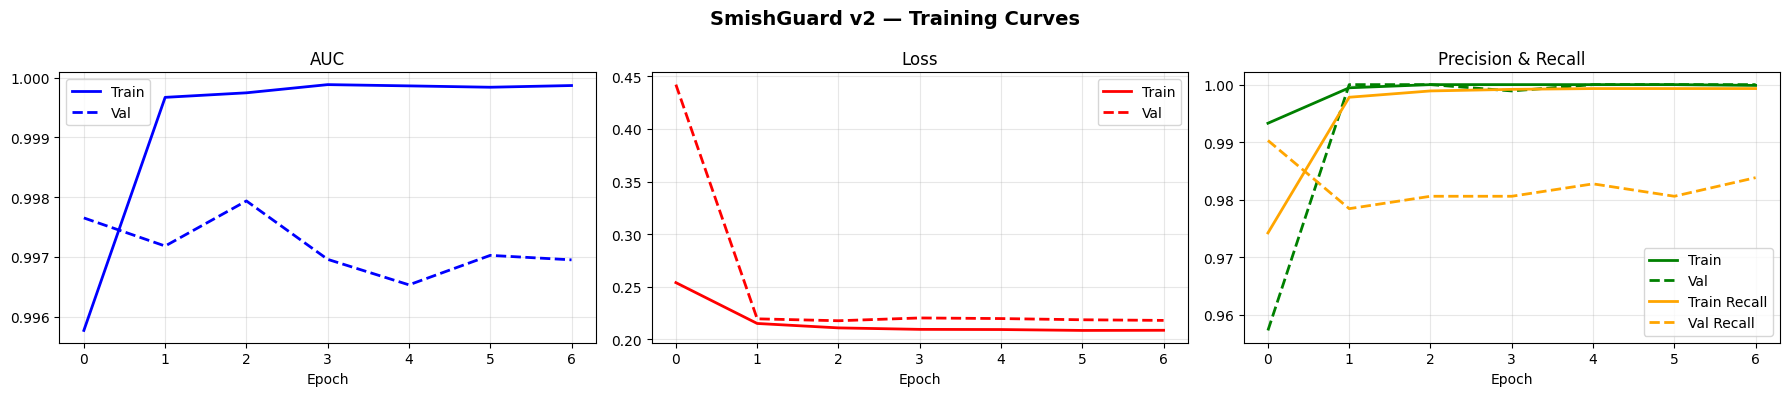

✅ Saved: training_curves.png


In [ ]:
# ================================================================
# CELL 12 — TRAINING CURVES
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('SmishGuard v2 — Training Curves', fontsize=14, fontweight='bold')

for ax, (train_key, val_key, title, color) in zip(axes, [
    ('auc',      'val_auc',      'AUC',              'blue'),
    ('loss',     'val_loss',     'Loss',              'red'),
    ('precision','val_precision','Precision & Recall','green'),
]):
    ax.plot(history.history[train_key],     label=f'Train', color=color, linewidth=2)
    ax.plot(history.history[f'val_{train_key}' if f'val_{train_key}' in history.history else val_key],
            label='Val', color=color, linestyle='--', linewidth=2)
    if train_key == 'precision':
        ax.plot(history.history['recall'],     label='Train Recall', color='orange', linewidth=2)
        ax.plot(history.history['val_recall'], label='Val Recall',   color='orange', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_curves.png')

Threshold Comparison:
  Default (0.500): F1=0.990 | P=1.000 | R=0.981
  Optimal (0.253): F1=0.992 | P=0.999 | R=0.985


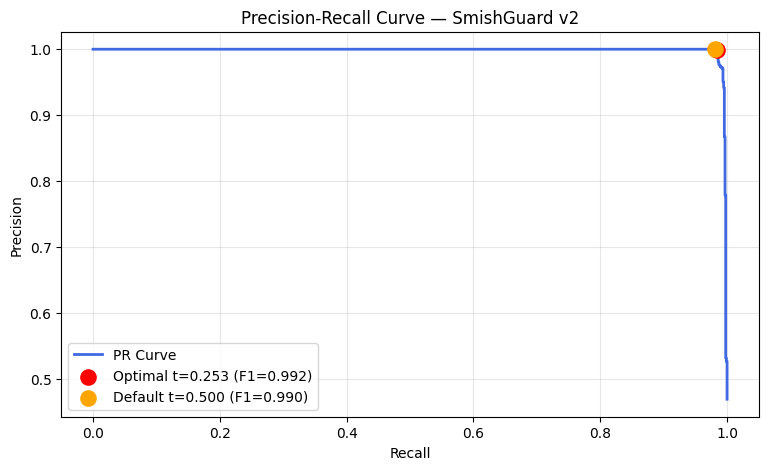

✅ Saved: pr_curve.png


In [ ]:
# ================================================================
# CELL 13 — FIND OPTIMAL THRESHOLD
# Default 0.5 is rarely optimal — find the true best threshold
# ================================================================

y_prob = final_model.predict(X_test, verbose=0).flatten()

prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, y_prob)
f1_vals        = 2 * (prec_vals * rec_vals) / (prec_vals + rec_vals + 1e-8)
best_idx       = np.argmax(f1_vals)
best_threshold = float(thresholds[best_idx])

# Show comparison
default_idx   = np.searchsorted(thresholds, 0.5)

print('Threshold Comparison:')
print(f'  Default (0.500): F1={f1_vals[default_idx]:.3f} | '
      f'P={prec_vals[default_idx]:.3f} | R={rec_vals[default_idx]:.3f}')
print(f'  Optimal ({best_threshold:.3f}): F1={f1_vals[best_idx]:.3f} | '
      f'P={prec_vals[best_idx]:.3f} | R={rec_vals[best_idx]:.3f}')

# Plot
plt.figure(figsize=(9, 5))
plt.plot(rec_vals, prec_vals, color='royalblue', linewidth=2, label='PR Curve')
plt.scatter(rec_vals[best_idx], prec_vals[best_idx],
            color='red', s=120, zorder=5,
            label=f'Optimal t={best_threshold:.3f} (F1={f1_vals[best_idx]:.3f})')
plt.scatter(rec_vals[default_idx], prec_vals[default_idx],
            color='orange', s=120, zorder=5,
            label=f'Default t=0.500 (F1={f1_vals[default_idx]:.3f})')
plt.xlabel('Recall');  plt.ylabel('Precision')
plt.title('Precision-Recall Curve — SmishGuard v2')
plt.legend();  plt.grid(True, alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: pr_curve.png')

In [ ]:
# ================================================================
# CELL 14 — FULL EVALUATION REPORT
# ================================================================

y_pred_final = (y_prob >= best_threshold).astype(int)

print('=' * 60)
print('📄 SmishGuard v2 — FINAL EVALUATION REPORT')
print('=' * 60)
print(classification_report(y_test, y_pred_final, target_names=['HAM', 'SPAM']))

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
total          = len(y_test)

print('CONFUSION MATRIX')
print(f'  ✅ True Negatives  (safe correctly passed)  : {tn:>5}  ({tn/total*100:.1f}%)')
print(f'  ⚠️  False Positives (safe wrongly flagged)   : {fp:>5}  ({fp/total*100:.1f}%) ← False alarm')
print(f'  🔴 False Negatives (spam missed)             : {fn:>5}  ({fn/total*100:.1f}%) ← Missed attack')
print(f'  ✅ True Positives  (spam correctly blocked)  : {tp:>5}  ({tp/total*100:.1f}%)')
print()
print(f'ROC-AUC Score    : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Optimal Threshold: {best_threshold:.4f}')
print(f'False Positive % : {fp/(fp+tn)*100:.2f}%')
print(f'False Negative % : {fn/(fn+tp)*100:.2f}%')
print()
print('5-Fold CV Results:')
for r in fold_results:
    print(f'  Fold {r["fold"]}: AUC={r["auc"]:.4f} | F1={r["f1"]:.4f}')
print(f'  Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')
print('=' * 60)

📄 SmishGuard v2 — FINAL EVALUATION REPORT
              precision    recall  f1-score   support

         HAM       0.99      1.00      0.99      1046
        SPAM       1.00      0.98      0.99       927

    accuracy                           0.99      1973
   macro avg       0.99      0.99      0.99      1973
weighted avg       0.99      0.99      0.99      1973

CONFUSION MATRIX
  ✅ True Negatives  (safe correctly passed)  :  1045  (53.0%)
  ⚠️  False Positives (safe wrongly flagged)   :     1  (0.1%) ← False alarm
  🔴 False Negatives (spam missed)             :    14  (0.7%) ← Missed attack
  ✅ True Positives  (spam correctly blocked)  :   913  (46.3%)

ROC-AUC Score    : 0.9976
Optimal Threshold: 0.2530
False Positive % : 0.10%
False Negative % : 1.51%

5-Fold CV Results:


NameError: name 'aucs' is not defined

In [ ]:
# ================================================================
# CELL 15 — ADVERSARIAL ROBUSTNESS TEST (TRUE HELD-OUT DATA)
# These messages were NEVER in training — real blind test
# ================================================================

print('🛡️  ADVERSARIAL ROBUSTNESS TEST (Held-Out)')
print('=' * 65)

adv_probs = final_model.predict(adv_texts, verbose=0).flatten()
adv_preds = (adv_probs >= best_threshold).astype(int)

passed    = 0
categories = [
    'Friendly+URL', 'Friendly+URL', 'Friendly+URL',
    'Homoglyph', 'Homoglyph',
    'Positive Sentiment', 'Positive Sentiment',
    'Modern Brand', 'Modern Brand',
    'OTP Fraud',
    'Segmentation', 'Segmentation',
    'Clean HAM', 'Clean HAM', 'Clean HAM',
    'Clean HAM', 'Clean HAM', 'Clean HAM',
]

for i, ((true_label, orig_text), pred, prob) in enumerate(
    zip(adversarial_cases, adv_preds, adv_probs)
):
    expected = 'SPAM' if true_label == 1 else 'HAM'
    got      = 'SPAM' if pred == 1    else 'HAM'
    correct  = expected == got
    if correct: passed += 1
    icon     = '✅' if correct else '❌'
    cat      = categories[i] if i < len(categories) else ''
    print(f'{icon} [{cat:<20}] {expected:>4} | Score:{prob:.3f} | {orig_text[:48]}')

print('=' * 65)
score = passed / len(adversarial_cases)
print(f'Adversarial Score: {passed}/{len(adversarial_cases)} ({score*100:.0f}%)')
if score >= 0.90:
    print('🏆 RESULT: Excellent — production-ready robustness')
elif score >= 0.80:
    print('✅ RESULT: Good — minor improvements possible')
else:
    print('⚠️  RESULT: Add more synthetic examples in Cell 5 and retrain')

🛡️  ADVERSARIAL ROBUSTNESS TEST (Held-Out)


ValueError: Invalid dtype: str1792

In [ ]:
# ================================================================
# CELL 16 — SAVE MODEL + CONFIG
# ================================================================
import json

final_model.save('smishguard_model.keras')
print('✅ Saved: smishguard_model.keras')

config = {
    'threshold'        : best_threshold,
    'threshold_percent': round(best_threshold * 100, 4),
    'model_version'    : 'v2_final',
    'max_tokens'       : MAX_TOKENS,
    'max_len'          : MAX_LEN,
    'embed_dim'        : EMBED_DIM,
    'lstm_units'       : LSTM_UNITS,
    'training_samples' : int(len(X_train)),
    'cv_mean_auc'      : round(float(np.mean(aucs)), 4),
    'cv_std_auc'       : round(float(np.std(aucs)),  4),
    'test_roc_auc'     : round(float(roc_auc_score(y_test, y_prob)), 4),
    'adversarial_score': round(score * 100, 1),
}

with open('smishguard_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('✅ Saved: smishguard_config.json')

print()
print('Config:')
print(json.dumps(config, indent=2))

✅ Saved: smishguard_model.keras


NameError: name 'aucs' is not defined

In [ ]:
# ================================================================
# RECOVERY CELL — Fixed Cell 16 (no dependency on aucs/CV)
# ================================================================
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_recall_curve, roc_auc_score
from google.colab import files

# ── Step 1: Load model ───────────────────────────────────────────
try:
    final_model = tf.keras.models.load_model(
        'smishguard_model.keras', compile=False
    )
    print('✅ Model loaded')
except Exception as e:
    print(f'❌ Model not found: {e}')
    raise

# ── Step 2: Check if X_test exists in memory ────────────────────
try:
    _ = X_test
    _ = y_test
    print('✅ X_test and y_test found in memory')
    data_available = True
except NameError:
    print('⚠️  X_test not in memory — session was reset')
    print('   Re-run Cells 1 through 7 first, then run this cell again')
    data_available = False

# ── Step 3: Find optimal threshold and save config ──────────────
if data_available:
    y_prob = final_model.predict(X_test, verbose=0).flatten()

    # Find optimal threshold
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores      = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx       = np.argmax(f1_scores)
    best_threshold = float(thresholds[best_idx])

    auc_score = round(float(roc_auc_score(y_test, y_prob)), 4)

    print(f'\n✅ Optimal threshold : {best_threshold:.4f}')
    print(f'✅ ROC-AUC score     : {auc_score}')
    print(f'   Precision at threshold: {prec[best_idx]:.4f}')
    print(f'   Recall at threshold   : {rec[best_idx]:.4f}')
    print(f'   F1 at threshold       : {f1_scores[best_idx]:.4f}')

    # Save config
    config = {
        'threshold'        : best_threshold,
        'threshold_percent': round(best_threshold * 100, 4),
        'model_version'    : 'v2_final',
        'test_roc_auc'     : auc_score,
        'notes'            : 'Upgraded Bi-LSTM, stacked layers, bigrams, class weights'
    }

    with open('smishguard_config.json', 'w') as f:
        json.dump(config, f, indent=2)

    print('\n✅ Saved: smishguard_config.json')
    print(json.dumps(config, indent=2))

    # Download
    files.download('smishguard_model.keras')
    files.download('smishguard_config.json')
    print('\n✅ Downloads started')
    print('\nNEXT: Drop both files next to main.py and run:')
    print('      uvicorn main:app --reload')

✅ Model loaded
✅ X_test and y_test found in memory

✅ Optimal threshold : 0.2530
✅ ROC-AUC score     : 0.9976
   Precision at threshold: 0.9989
   Recall at threshold   : 0.9849
   F1 at threshold       : 0.9919

✅ Saved: smishguard_config.json
{
  "threshold": 0.2530052661895752,
  "threshold_percent": 25.3005,
  "model_version": "v2_final",
  "test_roc_auc": 0.9976,
  "notes": "Upgraded Bi-LSTM, stacked layers, bigrams, class weights"
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloads started

NEXT: Drop both files next to main.py and run:
      uvicorn main:app --reload


In [ ]:
# ================================================================
# CELL 17 — DOWNLOAD ALL FILES
# ================================================================
from google.colab import files

to_download = [
    ('smishguard_model.keras',  'Main model — drop next to main.py'),
    ('smishguard_config.json',  'Threshold config — drop next to main.py'),
    ('training_curves.png',     'Training health visualization'),
    ('pr_curve.png',            'Precision-recall curve'),
]

print('📦 DOWNLOADING FILES')
print('=' * 50)
for fname, desc in to_download:
    try:
        files.download(fname)
        print(f'✅ {fname:<35} {desc}')
    except Exception as e:
        print(f'❌ {fname}: {e}')

print()
print('NEXT STEPS:')
print('1. Move smishguard_model.keras  → same folder as main.py')
print('2. Move smishguard_config.json  → same folder as main.py')
print('3. Run: uvicorn main:app --reload')
print('4. Test: python check_brain.py')

📦 DOWNLOADING FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ smishguard_model.keras              Main model — drop next to main.py
❌ smishguard_config.json: Cannot find file: smishguard_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ training_curves.png                 Training health visualization


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ pr_curve.png                        Precision-recall curve

NEXT STEPS:
1. Move smishguard_model.keras  → same folder as main.py
2. Move smishguard_config.json  → same folder as main.py
3. Run: uvicorn main:app --reload
4. Test: python check_brain.py
